# Free-to-play Versus Paid Games' Player Retention on Steam 
MATH 189 SP 26

## 0 Info
Group 41 Team:
- Ashley Vo
- Ana Guzman
- Julian Zaw
- Kangnan Ye
- Tony Tran

Acknowledgements:
- ChatGPT and Claude were used for assistance in our project.

<br>

---

## 1 Introduction
### 1.1 Background
Steam is a platform for personal computer (PC) games, offering a storefront, streaming service, social networking, and many other features. More specifically, Steam offers a vast platform for game developers to share and sell their games. 

There are two primary pricing models that we're interested in analyzing: free-to-play (often abbreivated as F2P) and paid. A free-to-play game is one that does not require an upfront cost to download and play the game. In other words, it can be thought of as costing "$0" as the name suggests. A paid game is one that requires a cost to download and play.

<br>

### 1.2 Research Question
> For games released before 2025, do the top 50 free-to-play games have stronger player retention compared to top 50 paid games in the long-term through their review and player count trends on Steam?

Here, we define "top" games as ones through their estimated ownership, total review count, and launch-period player count. We will not be paying special attention to games that have changed pricing models e.g. paid to free-to-play. There are more details on that in our analysis and limitations section.

<br>

### 1.3 Expectations
We expect free-to-play games to have larger initial player counts and possibly stronger long-term retention due to their accessibility in comparison. However, the question does not account for game genres, multiplayer or live-service status, etc.

<br>

### 1.4 Motivations
From a developer and business perspective, this is a choice that must be made in the industry. Developers may be interested in making a game more accessible by making it free-to-play, but that brings up a question of where and how developers would recuperate development costs if an upfront cost is not required. Player retention is something we're interested in investigating as a sustainable player base could contribute to a game's popularity and possibly support the developers finanicially if microtransactions are present.

<br>

---

<br>

## 2 Data
There are a couple of sources where our data was obtained from:
- Steam
- SteamCharts
- Kaggle

On Kaggle, our team worked with "Steam Dataset 2025" by Artemiy Ermilov (https://www.kaggle.com/datasets/artermiloff/steam-games-dataset). This dataset contains a variety of useful attributes for us like price, genres, estimated ownership, etc. This is the set we used to determine what was a top 50 in each category.

Steam (https://store.steampowered.com/) is the official site. Much in our interest, individual game pages have an option to view a chart of the game's historical review data. Thus, we scraped the website for this data after receiving the list of the top 50 games in each category.

SteamCharts (https://steamcharts.com/) provides average and peak player count data per month since a game's release. This website was scraped once we gathered the top 50 games from each category. However, due to a data availability error, we were only able to obtain 47 of the 50 paid games' player data. Please see the limitations section for more details.

<br>

---

<br>

## 3 EDA

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

from pathlib import Path
from scipy import stats

There are some custom functions that we have created for analysis. To prevent their length from taking away from the analysis, they will instead be imported as a module.

In [2]:
%load_ext autoreload
%autoreload 2
from modules import eda, stat_inf

<br>

### 3.1 Data Inspecting
First, we'll examine and explore the data of the top 50 free and paid games list.

In [3]:
df_free = pd.read_csv('data/top50_free_games_list.csv')
df_paid = pd.read_csv('data/top50_paid_games_list.csv')

print(df_free.head(), df_paid.head())

     AppID           Game Title Release Date Estimated Owners  \
0      730     Counter-Strike 2   2012-08-21            100M+   
1      570               Dota 2   2013-07-09            100M+   
2   578080  PUBG: BATTLEGROUNDS   2017-12-21       50M - 100M   
3  1172470         Apex Legends   2020-11-04       50M - 100M   
4   230410             Warframe   2013-03-25       50M - 100M   

   Peak Concurrent Players (24h)  
0                        1415913  
1                         632090  
2                         798913  
3                         277066  
4                          75491       AppID                 Game Title Release Date Base Price Estimated Owners  \
0  271590  Grand Theft Auto V Legacy   2015-04-13     $29.99       50M - 100M   
1  105600                   Terraria   2011-05-16      $9.99        20M - 50M   
2  292030   The Witcher 3: Wild Hunt   2015-05-18     $39.99        20M - 50M   
3    4000                Garry's Mod   2006-11-29      $9.99        20M - 5

In [4]:
df_free.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   AppID                          50 non-null     int64
 1   Game Title                     50 non-null     str  
 2   Release Date                   50 non-null     str  
 3   Estimated Owners               50 non-null     str  
 4   Peak Concurrent Players (24h)  50 non-null     int64
dtypes: int64(2), str(3)
memory usage: 2.1 KB


By looking at the data types, we observe estimated ownership is a string, so we will need to modify it later to work with it nicely. We can expect this is the same of the paid games dataset as they come from the same source as seen above the `.info()`.

Lastly, let's ensure there are no nulls in either dataset.

In [5]:
print('Number of non-nulls in free games dataset:\n', df_free.notna().sum(), '\n')
print('Number of non-nulls in paid games dataset:\n', df_paid.notna().sum())

Number of non-nulls in free games dataset:
 AppID                            50
Game Title                       50
Release Date                     50
Estimated Owners                 50
Peak Concurrent Players (24h)    50
dtype: int64 

Number of non-nulls in paid games dataset:
 AppID                            50
Game Title                       50
Release Date                     50
Base Price                       50
Estimated Owners                 50
Peak Concurrent Players (24h)    50
dtype: int64


Now, let's examine the player data.

In [6]:
df_free_players = pd.read_csv('data/top50_free_games_player_data.csv')
df_paid_players = pd.read_csv('data/top50_paid_games_player_data.csv')

print(df_free_players.head(), df_paid_players.head())

   game_id         game_name year_month  peak_player_count  \
0      730  Counter-Strike 2    2026-04            1564830   
1      730  Counter-Strike 2    2026-03            1717624   
2      730  Counter-Strike 2    2026-02            1627561   
3      730  Counter-Strike 2    2026-01            1654355   
4      730  Counter-Strike 2    2025-12            1620137   

   average_player_count  
0             974785.71  
1            1069173.12  
2            1084094.59  
3            1070443.78  
4             991176.89      game_id                  game_name year_month  peak_player_count  \
0   271590  Grand Theft Auto V Legacy    2026-04             108812   
1   271590  Grand Theft Auto V Legacy    2026-03             127424   
2   271590  Grand Theft Auto V Legacy    2026-02             127027   
3   271590  Grand Theft Auto V Legacy    2026-01             129542   
4   271590  Grand Theft Auto V Legacy    2025-12             136591   

   average_player_count  
0              617

In [7]:
df_free_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   game_id               5015 non-null   int64  
 1   game_name             5015 non-null   str    
 2   year_month            5015 non-null   str    
 3   peak_player_count     5015 non-null   int64  
 4   average_player_count  5015 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 196.0 KB


The data types are as expected, and like before, since the data for the paid games player data comes from the same source, we can safely assume both have the same data types.

<br>

### 3.2 Average player count trends
Now, let's observe the general trends of player data, starting with the distribution of player counts.

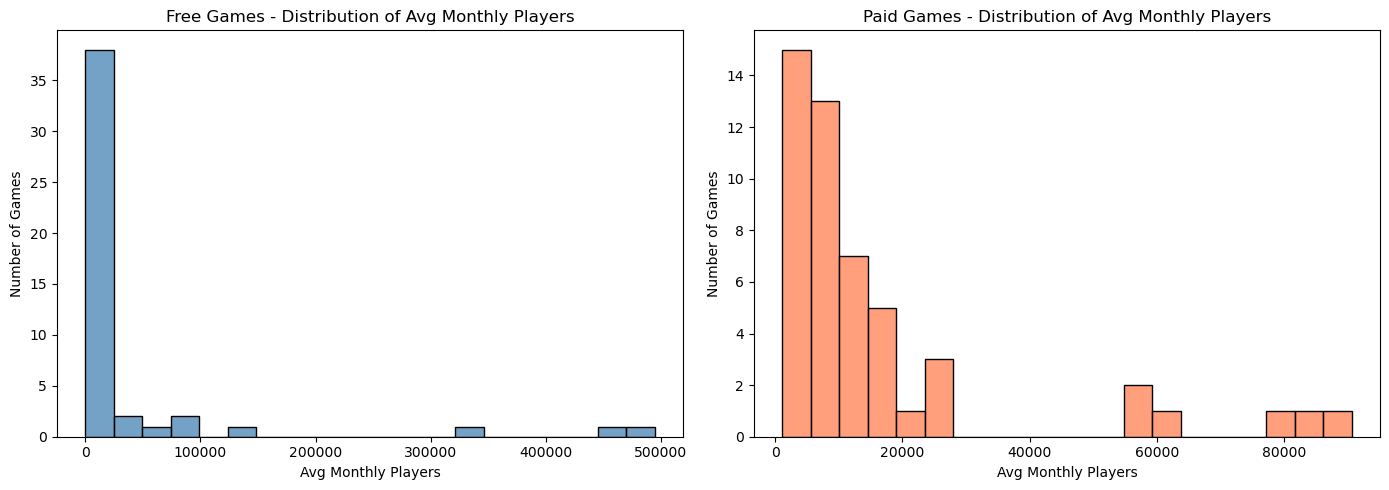

In [8]:
df_free_agg = df_free_players.groupby('game_id')['average_player_count'].mean()
df_paid_agg = df_paid_players.groupby('game_id')['average_player_count'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_free_agg, bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('Free Games - Distribution of Avg Monthly Players')
axes[0].set_xlabel('Avg Monthly Players')
axes[0].set_ylabel('Number of Games')

sns.histplot(df_paid_agg, bins=20, ax=axes[1], color='coral')
axes[1].set_title('Paid Games - Distribution of Avg Monthly Players')
axes[1].set_xlabel('Avg Monthly Players')
axes[1].set_ylabel('Number of Games')

plt.tight_layout()
plt.show()

Both have extreme right skews, so to adjust for that, we'll plot it on the log scale.

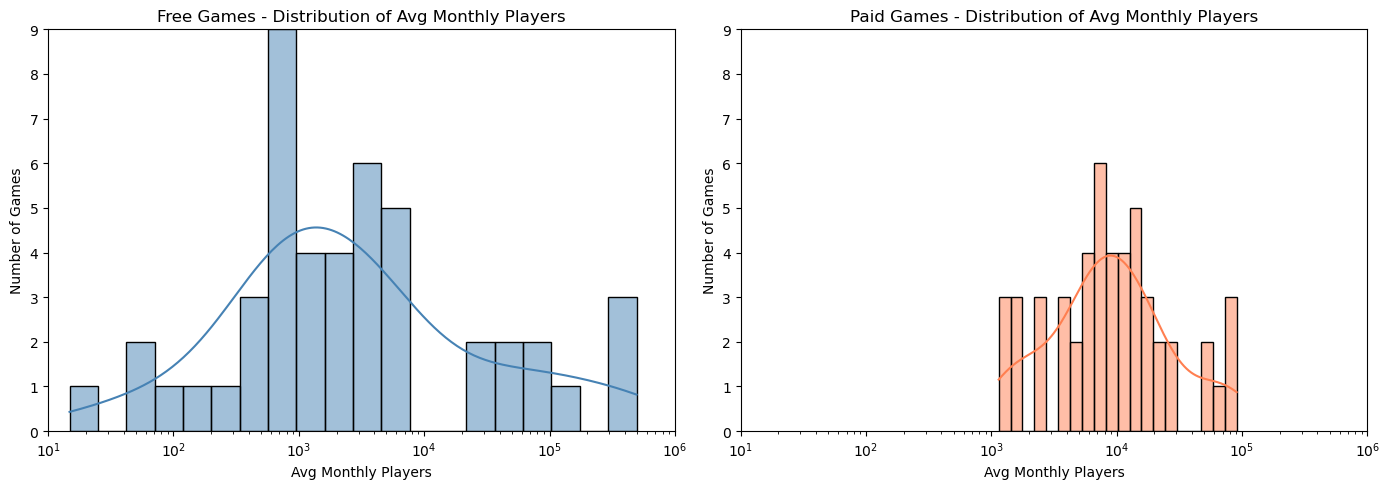

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_free_agg, bins=20, kde=True, ax=axes[0], log_scale=True, color='steelblue')
axes[0].set_title('Free Games - Distribution of Avg Monthly Players')
axes[0].set_xlabel('Avg Monthly Players')
axes[0].set_ylabel('Number of Games')
axes[0].set_xlim(1e1, 1e6)
axes[0].set_ylim(0, 9)

sns.histplot(df_paid_agg, bins=20, kde=True, ax=axes[1], log_scale=True, color='coral')
axes[1].set_title('Paid Games - Distribution of Avg Monthly Players')
axes[1].set_xlabel('Avg Monthly Players')
axes[1].set_ylabel('Number of Games')
axes[1].set_xlim(1e1, 1e6)
axes[1].set_ylim(0, 9)

plt.tight_layout()
plt.show()

While the distributions are similar, it's apparent the paid games are more tightly bunched with games not having a big spread of average players in comparison to free games.

Let's look at game activity over time. To account for outliers in our dataset, we'll look at *median* average concurrent players.

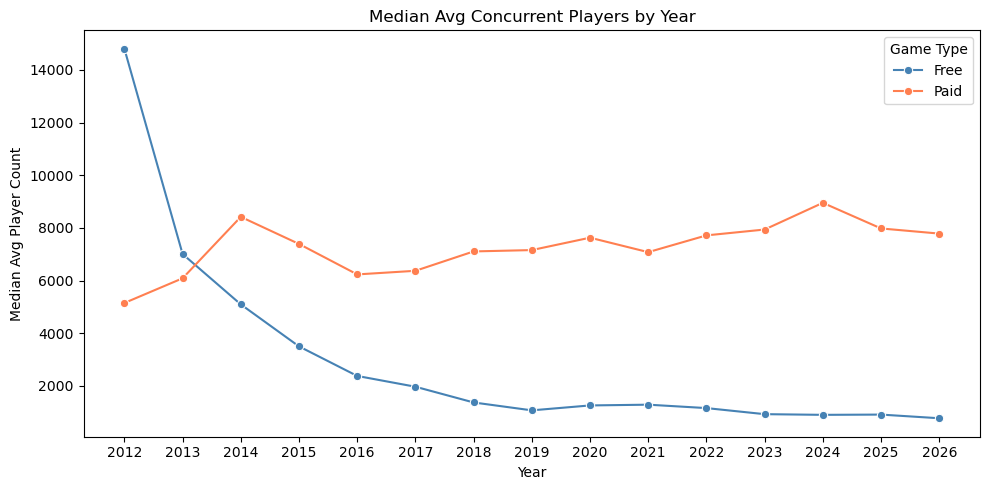

In [10]:
df_free_players['year'] = pd.to_datetime(df_free_players['year_month']).dt.year
df_paid_players['year'] = pd.to_datetime(df_paid_players['year_month']).dt.year

free_yearly = df_free_players.groupby('year')['average_player_count'].median()
paid_yearly = df_paid_players.groupby('year')['average_player_count'].median()

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(x=free_yearly.index, y=free_yearly.values, ax=ax, color='steelblue', marker='o', label='Free')
sns.lineplot(x=paid_yearly.index, y=paid_yearly.values, ax=ax, color='coral', marker='o', label='Paid')

ax.set_title('Median Avg Concurrent Players by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Median Avg Player Count')
ax.set_xticks(sorted(set(free_yearly.index) | set(paid_yearly.index)))
ax.legend(title='Game Type')

plt.tight_layout()
plt.show()

Overtime, we see the median for free games drops drastically over time while paid games maintain a relatively stable trend. This perhaps suggests free games were much more popular back in the early 2010s but lost steam over time.

<br>

### 3.3 Retention ratios
Now, let's look at the spread of median player counts.

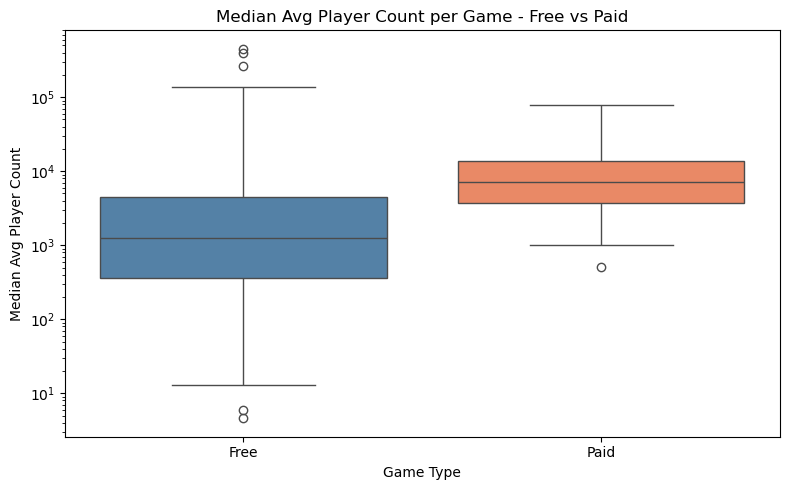

In [11]:
free_yearly = df_free_players.groupby('game_name')['average_player_count'].median().reset_index()
paid_yearly = df_paid_players.groupby('game_name')['average_player_count'].median().reset_index()

free_yearly['type'] = 'Free'
paid_yearly['type'] = 'Paid'

combined = pd.concat([free_yearly, paid_yearly])

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=combined, x='type', 
            y='average_player_count', 
            log_scale=True,
            hue='type',
            legend=False, 
            palette={'Free': 'steelblue', 'Paid': 'coral'},
            ax=ax)

ax.set_title('Median Avg Player Count per Game - Free vs Paid')
ax.set_xlabel('Game Type')
ax.set_ylabel('Median Avg Player Count')

plt.tight_layout()
plt.show()

In comparison, paid games have smaller spread while free games have much larger spread. Due to the free pricing model, this makes sense. There may be well known free-to-play games that dominate the free-to-play playerbase.

Since we're interested in player retention, we need to transform our data to look at that then we can plot the distribution of retention ratios. Note that we are interested in the average player counts rather than peak when considering the retention ratio.

In [12]:
retention_free = eda.compute_retention(df_free_players)
retention_paid = eda.compute_retention(df_paid_players)

retention_paid = retention_paid.replace( [np.inf, -np.inf], np.nan)
retention_paid = retention_paid.dropna()
retention_free = retention_free.replace( [np.inf, -np.inf], np.nan)
retention_free = retention_free.dropna()

print(retention_free.head(), '\n\n', retention_paid.head())

                      first_players  last_players  retention_ratio
game_name                                                         
APB Reloaded                2482.45        225.48         0.090830
Action Taimanin              834.75        781.38         0.936065
AdVenture Capitalist       11629.53       1046.73         0.090006
Apex Legends               74957.26     124387.18         1.659441
BATTALION: Legacy              0.82          2.13         2.597561 

                     first_players  last_players  retention_ratio
game_name                                                       
Assetto Corsa                1.74       9828.48      5648.551724
Battlefield V             1163.34       3868.19         3.325073
BeamNG.drive                88.27      19526.97       221.218647
Black Myth: Wukong      970442.70       7854.38         0.008094
Borderlands 2            61242.78       2601.24         0.042474


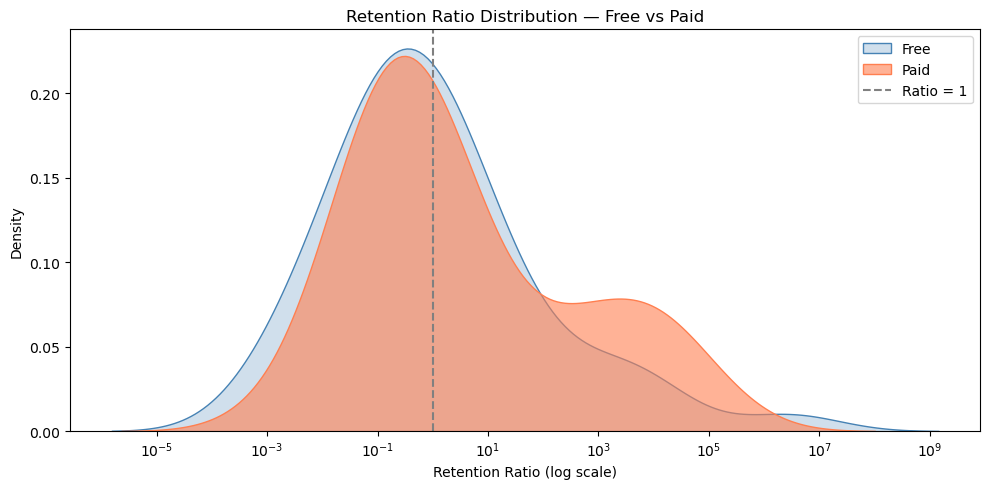

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(retention_free['retention_ratio'], ax=ax, color='steelblue', fill=True, label='Free', log_scale=True)
sns.kdeplot(retention_paid['retention_ratio'], ax=ax, color='coral', fill=True, label='Paid', log_scale=True, alpha=0.6)

ax.axvline(x=1, color='gray', linestyle='--', label='Ratio = 1')
ax.set_title('Retention Ratio Distribution — Free vs Paid')
ax.set_xlabel('Retention Ratio (log scale)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

An important thing to note is that a ratio of 1 means that the player retention has stayed the same since release. Generally speaking, both free and games have almost a similar distribution with some key differences. Both have their peaks between $10^{-1}$ and $10^{0}$, suggesting more games see decline over time. A significant difference is the fatter tail paid games have, suggetsing that there exists a sizable number of games that actually see growth rather than decline.

Due to the existence of outliers in our dataset, we may be interested in filtering out games that must have a minimum of 100 players average on release.

In [14]:
retention_free_filtered = retention_free[retention_free['first_players'] > 100]
retention_paid_filtered = retention_paid[retention_paid['first_players'] > 100]

print(f"Free games: {len(retention_free)} -> {len(retention_free_filtered)} after filter")
print(f"Paid games: {len(retention_paid)} -> {len(retention_paid_filtered)} after filter")

Free games: 46 -> 35 after filter
Paid games: 49 -> 36 after filter


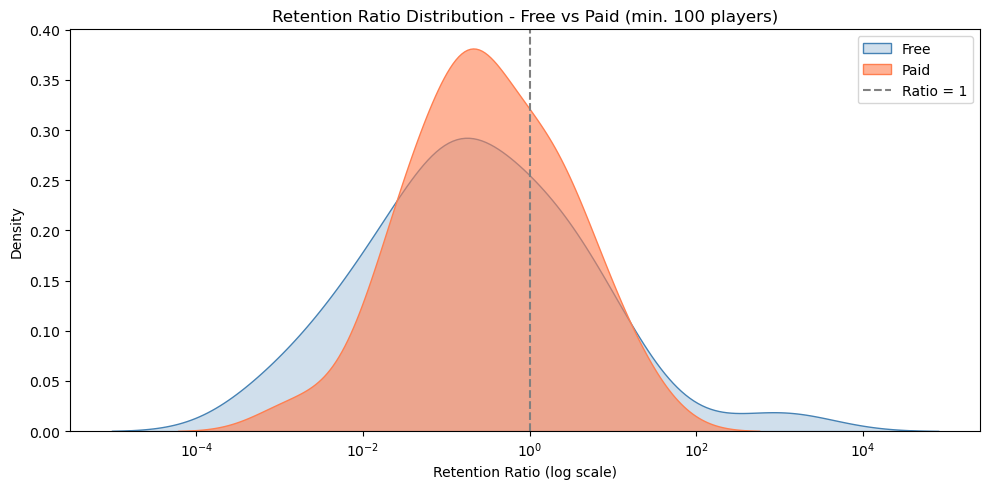

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(retention_free_filtered['retention_ratio'], ax=ax, color='steelblue', fill=True, label='Free', log_scale=True)
sns.kdeplot(retention_paid_filtered['retention_ratio'], ax=ax, color='coral', fill=True, label='Paid', log_scale=True, alpha=0.6)

ax.axvline(x=1, color='gray', linestyle='--', label='Ratio = 1')
ax.set_title('Retention Ratio Distribution - Free vs Paid (min. 100 players)')
ax.set_xlabel('Retention Ratio (log scale)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

Paid games have a much tighter distribution while free games have a wider one. Free games have extremes with games seeing major loss but also major growth. Despite our analysis not going into the details of genres, like being live service, we assume this may be a large contributing factor.

<br>

---

<br>

## 4 Statistical Inference

For the following, we choose significance level $\alpha = 0.05$ for our analysis.

<br>

### 4.1 Means of retention ratios
Something we're interested in is asking is whether the mean retention is truly different between free-to-play and paid games. As such, we'll use Welch's t-test as we do not want to assume equal variances between the two groups.

Our set-up is as follows:
- $H_{0} : \mu_{\text{free}} = \mu_{\text{paid}}$
- $H_{a} : \mu_{\text{free}} \neq \mu_{\text{paid}}$
where "free" and "paid" represent the free-to-play and paid games, respectively.

In [16]:
# Welch's t-test on raw retention ratio
t_stat, p_value = stats.ttest_ind(
    retention_free['retention_ratio'],
    retention_paid['retention_ratio'],
    equal_var=False
)

print("t-statistic =", t_stat)
print("p-value =", p_value)

# Welch's t-test on log retention ratio
t_stat_log, p_value_log = stats.ttest_ind(
    np.log(retention_free['retention_ratio']),
    np.log(retention_paid['retention_ratio']),
    equal_var=False
)

print("\nlog t-statistic =", t_stat_log)
print("log p-value =", p_value_log)

t-statistic = 0.9231781462117606
p-value = 0.36081029761229655

log t-statistic = -1.281385210712014
log p-value = 0.20324476278890644


For both tests on the raw and log-scaled data, both p-values are greater than our chosen $\alpha = 0.05$, thus we fail to reject our null hypothesis. In other words, the means between the two groups are the same. This lines up with our inspection of the distribution visualizations.

<br>

### 4.2 True difference between retention ratios
Since Welch's t-test did not give us meaningful insight, another question we may be interested in is whether two randomly chosen games from free-to-play and paid consistently have higher/lower retention ratios than the other. In other words, do they come from the same distribution? Due to the normality assumption, we'll work with the log-scaled data.

Our set-up is as follows:
- $H_0 : \text{The two distributions are identical}$
- $H_a : \text{The two distributions are not identical}$

In [17]:
retention_free_log = np.log(retention_free['retention_ratio'])
retention_paid_log = np.log(retention_paid['retention_ratio'])

u_stat, p_value_mw = stats.mannwhitneyu(retention_free_log, retention_paid_log, alternative='two-sided')
print("U-statistic =", u_stat)
print("p-value =", p_value_mw)

U-statistic = 980.0
p-value = 0.2752829142706459


Given the test's p-value $\approx 0.275$, this is greater than our $\alpha = 0.05$, so we fail to reject the null hypothesis. In other words, the distributions are identical. However, from our analysis of the distributions in the EDA section, we noticed different shapes, so this may be due to the lack of signficant evidence. Regardless, we cannot conclude that paid or free-to-play games exhibit stronger long-term player retention than the other.

<br>

### 4.3 Confidence intervals for mean log retention
Now, based on the log retention ratios, let's construct a confidence interval for the difference in means where our parameter of interest is
$$
    \mu_{\text{free}} - \mu_{\text{paid}}
$$

In [18]:
n1 = len(retention_free_log)
n2 = len(retention_paid_log)

mean1 = retention_free_log.mean()
mean2 = retention_paid_log.mean()

var1 = retention_free_log.var(ddof=1)
var2 = retention_paid_log.var(ddof=1)

print("Mean log retention (free):", mean1)
print("Mean log retention (paid):", mean2)

# Standard error
SE = np.sqrt(var1/n1 + var2/n2)

# Welch-Satterthwaite degrees of freedom
df_welch = (
    (var1/n1 + var2/n2)**2
) / (
    ((var1/n1)**2)/(n1-1)
    +
    ((var2/n2)**2)/(n2-1)
)

# Critical value
t_star = stats.t.ppf(0.975, df_welch)

# 95% CI for difference in means
difference = mean1 - mean2
lower = difference - t_star * SE
upper = difference + t_star * SE

print("\nDifference (free - paid) =", difference)
print("95% CI = [", lower, ",", upper, "]")

Mean log retention (free): 0.08021965720029552
Mean log retention (paid): 1.2771924113835933

Difference (free - paid) = -1.1969727541832977
95% CI = [ -3.0519625355398112 , 0.6580170271732155 ]


In this case, the confidence interval contains 0. This is consistent with our results from the Welch and Mann-Whitney tests earlier that there is no signficant difference between the two groups: free-to-play and paid. With 95% confidence, the true difference in their retentions must lie between $[-3.05, 0.66]$. An interesting observation is the wide interval, suggesting some variance in the data. Additionally, since the interval includes negative and positive ends, it also suggests that even free-to-play games have better retention than paid.

<br>

### 4.4 Bootstrapping

The parametric 95% confidence interval in 4.3 relies on log-retention being approximately normal. Since our sample sizes are modest ($n_{\text{free}} = 46$, $n_{\text{paid}} = 49$) and the distributions are visibly heavy-tailed, we re-estimate the interval with a nonparametric percentile bootstrap to check whether the parametric result depends on those assumptions.

The procedure is to:
1. Resample each group's per-game log-retention values with replacement
2. Recompute the statistic of interest 
3. Repeat $B = 10{,}000$ times
4. Read the central 95% of the bootstrap distribution
   
Because our analysis unit is one number per game, no clustering correction is needed beyond resampling games directly. We bootstrap both the mean difference (to compare to 4.3) and the median difference as a more robust compliment.

In [20]:
B = 10_000
rng = np.random.default_rng(189)

log_free_np = np.log(retention_free['retention_ratio'].to_numpy())
log_paid_np = np.log(retention_paid['retention_ratio'].to_numpy())

rows = []
for name, stat in [('mean', np.mean), ('median', np.median)]:
    diff_boot = stat_inf.boot_diff(log_free_np, log_paid_np, stat, B, rng)
    pt = stat(log_free_np) - stat(log_paid_np)
    lo, hi = stat_inf.pct_ci(diff_boot)
    rows.append({'statistic': f'{name} log(retention)',
                 'point_estimate (Free - Paid)': round(pt, 3),
                 '95% CI lower': round(lo, 3),
                 '95% CI upper': round(hi, 3),
                 'ratio scale': f"{np.exp(pt):.2f}x  [{np.exp(lo):.2f}, {np.exp(hi):.2f}]"})

pd.DataFrame(rows)

,statistic,point_estimate (Free - Paid),95% CI lower,95% CI upper,ratio scale
0,mean log(retention),-1.197,-3.011,0.573,"0.30x [0.05, 1.77]"
1,median log(retention),-0.579,-2.433,1.422,"0.56x [0.09, 4.14]"


The bootstrap mean-difference CI on the log scale is $[-3.01, 0.57]$, which is almost identical to the parametric Welch confidence interval $[-3.05, +0.66]$ from 4.3, so the t-based interval was reliable for this data.

We ran the test on $\log(\text{retention ratio})$, so the null hypothesis "the two groups have equal mean retention" corresponds to a mean log-difference of $0$. Back-transforming via $\exp(\cdot)$, the equivalent statement on the original retention-ratio scale is that the ratio of typical-free to typical-paid retention equals $1$. So a CI containing $0$ on the log scale is the same statement as a CI containing $1$ on the ratio scale.

The log-scale point estimate of $-1.197$ back-transforms to $\exp(-1.197) \approx 0.30$, which is the `0.30x` entry in the `ratio scale` column - the bootstrap's best single guess is that the typical free game's retention is about $30\%$ of the typical paid game's. The 95% CI is very wide on the ratio scale, running from $0.05$ (free much worse) to $1.77$ (free moderately better), and the null value $1$ sits inside it. The median-difference row tells the same story with more uncertainty: log-CI $[-2.43, +1.42]$, ratio-CI $[0.09, 4.14]$. Since both CIs include the null, at $\alpha = 0.05$ we fail to reject equal retention, consistent with the previous analyses.

<br>

#### 4.4.1 Retention by post-peak window

The single-number summary above averages across each game's entire post-launch history, which can hide time-scale effects: a launch-spike pattern (early retention high, late retention low) and a slow-burn pattern can produce the same overall ratio while behaving completely differently. To check this, we split each game's life into five post-peak windows and compute a window-specific retention ratio as
$$
r_w \;=\; \frac{\text{mean average players in window } w}{\text{game's peak monthly average}}
$$
A game contributes to a window only if its observed history extends into it. We then bootstrap the median $\text{free} - \text{paid}$ difference inside each window, with $B = 10{,}000$ and the same percentile method.

In [21]:
# windowed retention (one row per game per group)
WINDOWS = [(1, 6), (7, 12), (13, 24), (25, 48), (49, 96)]

w_free = stat_inf.windowed_retention(df_free_players, 'Free')
w_paid = stat_inf.windowed_retention(df_paid_players, 'Paid')

rows = []
for lo, hi in WINDOWS:
    col = f'{lo}-{hi}'
    fr = w_free[col].dropna().to_numpy()
    pa = w_paid[col].dropna().to_numpy()
    diff_boot = stat_inf.boot_diff(fr, pa, np.median, B, rng)
    pt = float(np.median(fr) - np.median(pa))
    lo_ci, hi_ci = stat_inf.pct_ci(diff_boot)
    rows.append({'window (mo post-peak)': col,
                 'n_free': len(fr), 'n_paid': len(pa),
                 'median Free': round(float(np.median(fr)), 3),
                 'median Paid': round(float(np.median(pa)), 3),
                 'Free - Paid': round(pt, 3),
                 '95% CI': f"[{lo_ci:+.3f}, {hi_ci:+.3f}]",
                 'excludes 0?': 'yes' if (lo_ci > 0 or hi_ci < 0) else 'no'})

windowed_summary = pd.DataFrame(rows)
windowed_summary

,window (mo post-peak),n_free,n_paid,median Free,median Paid,Free - Paid,95% CI,excludes 0?
0,1-6,47,50,0.569,0.414,0.154,"[-0.044, +0.292]",no
1,7-12,44,47,0.387,0.287,0.101,"[-0.088, +0.224]",no
2,13-24,42,45,0.279,0.275,0.003,"[-0.142, +0.126]",no
3,25-48,40,35,0.180,0.258,-0.078,"[-0.182, +0.067]",no
4,49-96,30,28,0.115,0.211,-0.096,"[-0.181, -0.037]",yes


Interestingly enough, it appears for months 1-12, free games have better retention than paid games. However, they equalize around the 13-24 month mark, and after that, paid games increase in retention over free-to-play games after 25 months (long-term). This suggests free-to-play games spike early but decay faster while paid games decay at a slower rate.

Another important thing to note is the shrinking size of the game pool over time. Due to the size of the data, less games will actually have long-term data available, which may not necessarily be reflective of the Steam games population as these are the top fifty games.

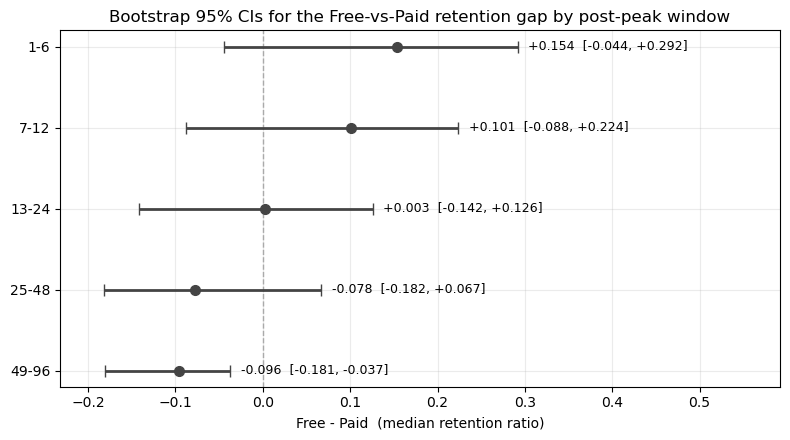

In [22]:
# Forest plot of the Free - Paid difference by window
labels = [r['window (mo post-peak)'] for r in rows]
pts = [r['Free - Paid'] for r in rows]
los = [float(r['95% CI'].split(',')[0].strip(' [')) for r in rows]
his = [float(r['95% CI'].split(',')[1].strip(' ]')) for r in rows]

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(labels))
ax.axvline(0, ls='--', color='#aaa', lw=1)
ax.errorbar(pts, y,
            xerr=[np.array(pts) - np.array(los), np.array(his) - np.array(pts)],
            fmt='o', color='#444', ecolor='#444', capsize=4, lw=2, markersize=7)
for i, (pt, lo, hi) in enumerate(zip(pts, los, his)):
    ax.text(hi + 0.012, i, f"{pt:+.3f}  [{lo:+.3f}, {hi:+.3f}]",
            va='center', fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlabel('Free - Paid  (median retention ratio)')
ax.set_title('Bootstrap 95% CIs for the Free-vs-Paid retention gap by post-peak window')
ax.grid(alpha=.25); ax.set_axisbelow(True)
ax.set_xlim(min(los) - 0.05, max(his) + 0.30)
plt.tight_layout(); plt.show()

Visually, this further supports the analysis above. Free-to-play games sit above paid games in the first year ($\text{free} - \text{paid} \approx 0.15$ at 1-6 months, $+0.10$ at 7-12 months), the gap closes near month 13-24, and then the sign begins to flip by 25-28 months. By 49-96 months post-peak the median paid game retains roughly 9.6 percentage points more of its peak than the median free game, with a 95% bootstrap CI of $[-0.181,\;-0.037]$ that excludes 0.

So at $\alpha = 0.05$ we reject equal retention at long horizons, even though the comparisons in 4.1-4.4 fail to reject. However, the two findings are not contradictory: the aggregate averages out a positive short-term gap and a negative long-term gap, which roughly cancel. 

There must be a separation. Free-to-play games hold a larger share of their peak in the launch year but lose it faster after, and the gap becomes statistically detectable only once we let time enter the analysis.

<br>

### 4.5 Review scores 
words for paired test

### 4.6 Modeling retention as a function of multiple variables
words

### 4.7 Confounds in the model
words

---

## 5 Results

Our central question was whether free-to-play games hold their players longer than paid games in the long run. The evidence across the EDA and the five inference subsections of §4 converges on an answer that is more nuanced than a single yes/no.

**Distributions and central tendency (§3, §4.1-4.3).** The two groups' retention-ratio distributions overlap heavily, with free games showing visibly wider spread driven by a handful of mega-hits and a long tail of abandoned titles. Welch's two-sample t-test on the raw retention ratio and on the log scale both fail to reject equal means ($p \approx 0.27$ and $p \approx 0.28$). The Mann-Whitney U test on log retention agrees ($p \approx 0.275$). The Welch 95% confidence interval for the mean log-retention difference, $[-3.05,\;+0.66]$, includes 0. At the aggregate level we **cannot conclude** that one pricing model yields stronger long-term retention than the other.

**Bootstrap validation (§4.4).** A nonparametric percentile bootstrap with $B = 10{,}000$ produces a mean-difference CI of $[-3.01,\;+0.57]$ on log retention, essentially indistinguishable from the parametric Welch interval. The bootstrap therefore confirms that the failure to reject in §4.1-4.3 is not an artifact of normality assumptions or the Welch-Satterthwaite approximation - the parametric interval is reliable for this data.

**Time-resolved retention (§4.4.1).** Splitting each game's history into post-peak windows changes the picture. Free games retain a larger share of their peak in the first year (median Free $-$ Paid $\approx +0.15$ at 1-6 months and $+0.10$ at 7-12 months, both CIs straddling 0), the gap closes around months 13-24, and then the sign flips. By 49-96 months post-peak the median paid game retains $\approx 9.6$ percentage points more of its peak than the median free game, with a 95% bootstrap CI of $[-0.181,\;-0.037]$ that **excludes 0**. The aggregate test failed to reject precisely because it averaged out a positive short-term gap and a negative long-term gap.

**Review-score trend (§4.5).** *To be inserted from Julian's paired-test analysis comparing launch-window and present-day review scores.*

**Regression and confounders (§4.6-4.7).** *To be inserted from Tony's regression of retention on free-to-play status, release year, launch player count, and multiplayer/online indicators, including the diagnostics from Weeks 5-7 and the free-to-play × multiplayer interaction.*

**Bottom line.** On the headline aggregate comparison, the data do not let us claim free-to-play has stronger long-term retention than paid - both Welch and Mann-Whitney fail to reject, and the parametric and bootstrap 95% CIs for the mean log-retention difference contain 0. The time-resolved bootstrap qualifies that conclusion: free-to-play games out-retain paid games in the launch year but underperform them on the multi-year horizon, and the long-horizon gap is statistically significant. Whether that pattern survives the regression adjustment for release year, launch size, and multiplayer status is what §4.6 will tell us.

---

## 6 Limitations
> ### [DRAFT]
- Reviews launched in 2013 ==> not reflective of game's literal launch impressions
- Some games moved from one model to another; did not consider this in analysis but acknowledged potential for outliers
- Wanted to analyze singleplayer versus multiplayer effect but we did not get that data.
- Only 47 rather than 50 paid games player data obtained; did not reconsider getting new data as we were constrained by time